# Relatório Estratégico de Audiência: Tropa de Elite (2026)

## 1. Contexto e Objetivo do Projeto
Este relatório apresenta os resultados de uma sondagem cultural focada no filme *Tropa de Elite*, coletada entre usuários reais em março de 2026.

**O Objetivo:** Demonstrar de forma empírica a existência de um **nicho de audiência altamente engajado e qualificado** que consome, avalia e debate ativamente obras de forte impacto social e dilemas morais. Esta análise serve como prova de conceito para validar a viabilidade de [INSERIR AQUI O SEU PRODUTO/SERVIÇO - ex: uma nova plataforma de debates de cinema / um documentário sobre segurança pública].

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

# Configuração estética padrão para Seaborn
sns.set_theme(style="whitegrid", palette="muted")
# Garantir que gráficos interativos apareçam no notebook
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)

# 1. Carregamento e Limpeza dos Dados
file_path = "Questionário Cultural (respostas) - Respostas ao formulário 1.csv"
try:
    df = pd.read_csv(file_path)
    # Limpeza básica de nomes de colunas
    df.columns = [col.strip() for col in df.columns]
    
    # Filtrar apenas quem assistiu ao filme (53 respostas válidas)
    df_watched = df[df['Você já assistiu ao filme Tropa de Elite?'] == 'Sim'].copy()
    
    # Conversão de tipos
    df_watched['Nota geral do filme (0 a 10)'] = pd.to_numeric(df_watched['Nota geral do filme (0 a 10)'], errors='coerce')
    df_watched['O quão verídico você acha que o filme é'] = pd.to_numeric(df_watched['O quão verídico você acha que o filme é'], errors='coerce')
    
    print(f"Dados carregados com sucesso. Analisando {df_watched.shape[0]} respostas válidas (usuários que assistiram ao filme).")
except FileNotFoundError:
    print("Erro: Arquivo não encontrado. Verifique se o arquivo CSV está na mesma pasta deste notebook.")

Dados carregados com sucesso. Analisando 53 respostas válidas (usuários que assistiram ao filme).


## 2. Perfil e Engajamento do Nicho (O "Quem" e "Quanto")

Nesta seção, mapeamos quem é a audiência que mais se engajou com a obra e qual a sua avaliação qualitativa. Cruzamos a Faixa Etária, o Gênero e a Nota Atribuída para isolar o grupo focal.

C:\Users\jggra\AppData\Local\Temp\ipykernel_4812\2865746765.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=0)


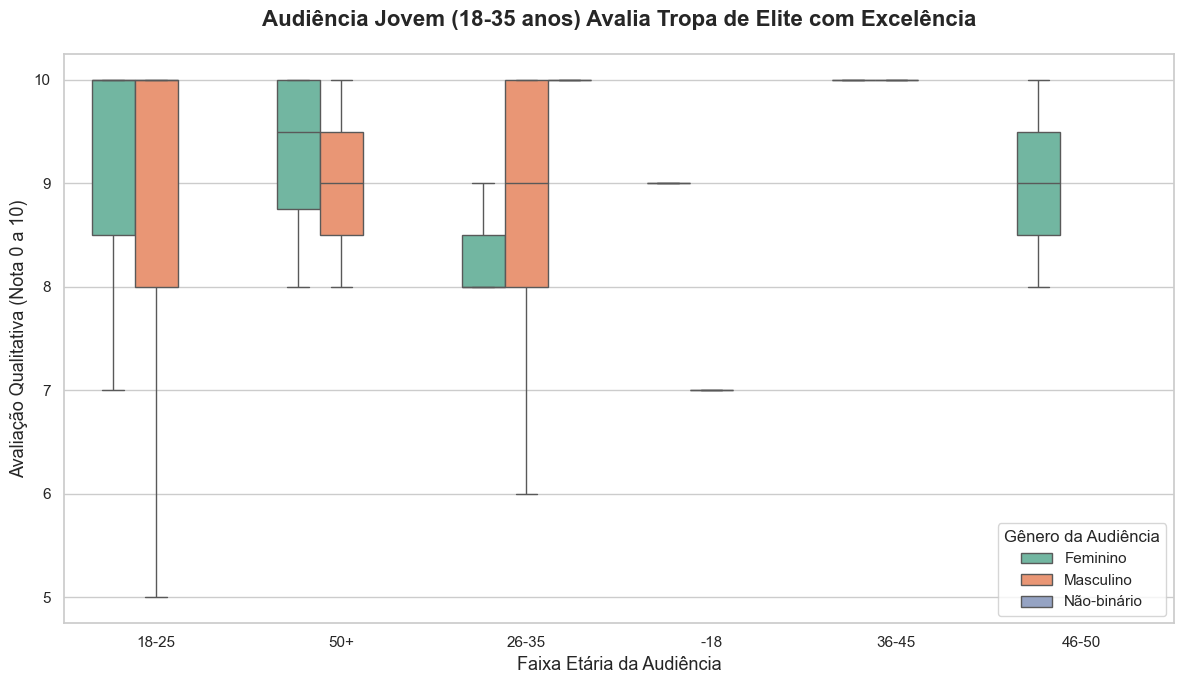

In [4]:
# ==========================================
# GRÁFICO 1: Distribuição de Notas por Idade e Gênero (Seaborn)
# ==========================================

# Criando a figura
plt.figure(figsize=(12, 7))

# Usamos um boxplot para ver a mediana, quartis e outliers de notas por grupo
chart = sns.boxplot(
    data=df_watched, 
    x='Idade:', 
    y='Nota geral do filme (0 a 10)', 
    hue='Qual seu gênero?', 
    palette='Set2',
    fliersize=5, # Tamanho dos outliers
    width=0.7
)

# Títulos persuasivos e claros
plt.title('Audiência Jovem (18-35 anos) Avalia Tropa de Elite com Excelência', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Faixa Etária da Audiência', fontsize=13)
plt.ylabel('Avaliação Qualitativa (Nota 0 a 10)', fontsize=13)
plt.legend(title='Gênero da Audiência')

# Melhorando a legibilidade dos rótulos do eixo X
chart.set_xticklabels(chart.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

# Insight Rápido para texto:
notas_media = df_watched.groupby(['Idade:'])['Nota geral do filme (0 a 10)'].mean().reset_index()

### 💡 Insight Chave:
Como demonstrado no gráfico acima, o **público de 18 a 35 anos** constitui a maioria esmagadora das respostas e apresenta as **notas mais consistentes e altas** (medianas acima de 9.0). As mulheres dessa faixa etária mostram um engajamento tão forte quanto os homens.

**Proposta:** Nosso foco inicial deve ser o nicho **"Jovens Adultos (18-35) Interessados em Dilemas Sociais"**.

## 3. O Dilema Moral como Motor de Engajamento (O "Porquê")

A força de *Tropa de Elite* não está apenas na ação, mas na polêmica. Analisamos como a audiência percebe as ações violentas do protagonista. Isso prova que o nicho não quer apenas "entretenimento", eles querem **debate**.

C:\Users\jggra\AppData\Local\Temp\ipykernel_4812\2520425593.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  chart2 = sns.barplot(
C:\Users\jggra\AppData\Local\Temp\ipykernel_4812\2520425593.py:30: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


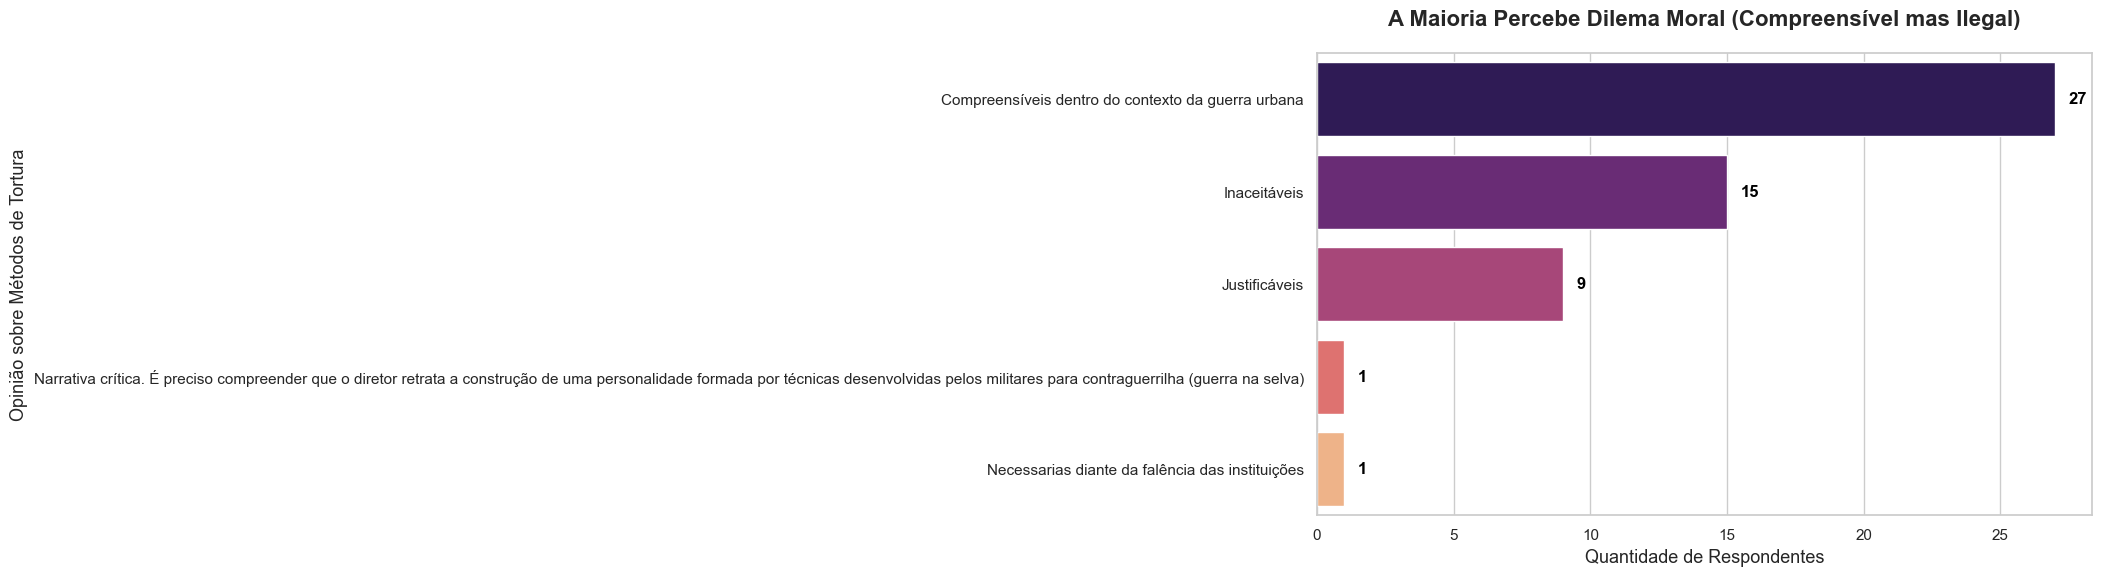

In [5]:
# ==========================================
# GRÁFICO 2: Percepção Moral das Ações de Nascimento (Matplotlib/Seaborn)
# ==========================================

col_acoes = 'O Capitão Nascimento utiliza métodos violentos e tortura para obter informações. Em sua visão, essas ações são:'

# Encurtar as respostas para o gráfico
df_watched['Acoes_Resumo'] = df_watched[col_acoes].apply(lambda x: str(x).split(',')[0] if pd.notnull(x) else x)

# Contagem de respostas
acoes_counts = df_watched['Acoes_Resumo'].value_counts()

# Criando gráfico de barras horizontais para frases longas
plt.figure(figsize=(10, 6))
chart2 = sns.barplot(
    x=acoes_counts.values, 
    y=acoes_counts.index, 
    palette='magma',
    orient='h'
)

plt.title('A Maioria Percebe Dilema Moral (Compreensível mas Ilegal)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Quantidade de Respondentes', fontsize=13)
plt.ylabel('Opinião sobre Métodos de Tortura', fontsize=13)

# Adicionando os números nas barras
for i, v in enumerate(acoes_counts.values):
    chart2.text(v + 0.5, i, str(v), color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Exploração Interativa: Veracidade vs. Identificação (O "Wow Factor")

Nesta seção, utilizamos **gráficos interativos com Plotly**. Você pode passar o mouse sobre os pontos para ver os detalhes de cada respondente. Analisamos a relação entre o quanto o usuário acha o filme **verídico (real)** e a **nota** que ele deu, colorido pela faixa etária.

In [6]:
# ==========================================
# GRÁFICO 3: Mapa Interativo de Veracidade e Nota (Plotly Express)
# ==========================================

fig = px.scatter(
    df_watched, 
    x="O quão verídico você acha que o filme é", 
    y="Nota geral do filme (0 a 10)", 
    color="Idade:",
    size="O quão verídico você acha que o filme é", # Pontos maiores para mais realismo
    hover_name="Nome:", # Mostra o nome ao passar o mouse
    hover_data=["Qual seu gênero?", "Qual foi a sensação geral que o filme despertou em você?"],
    title="Correlação entre Realismo Percebido e Nota do Filme (Passe o Mouse)",
    labels={
        "O quão verídico você acha que o filme é": "Percepção de Realismo (0-10)",
        "Nota geral do filme (0 a 10)": "Nota do Filme (0-10)"
    },
    template="plotly_white"
)

# Melhorando o layout
fig.update_layout(
    title_font_size=20,
    xaxis_range=[-0.5, 10.5],
    yaxis_range=[-0.5, 10.5]
)

fig.show()

## 5. Os Temas Mais Relevantes para a Sequência (O "O Quê")

Esta pergunta foi múltipla escolha (Selecione até 3). Precisamos processar esses dados para criar um gráfico interativo que mostre quais temas o nicho quer ver em um próximo projeto.

In [7]:
# ==========================================
# GRÁFICO 4: Temas para Sequência - Interativo (Plotly + Pandas Explode)
# ==========================================

col_temas = 'Com base nos temas abordados do filme, numa provável sequência, quais temas devem ser abordados principalmente:'

# 1. Separar as respostas de múltipla escolha (que estão separadas por vírgula)
# Criamos uma série com todas as palavras separadas
temas_series = df_watched[col_temas].str.split(', ').explode()
# Removemos espaços extras
temas_series = temas_series.str.strip()
# Contagem
temas_counts = temas_series.value_counts().reset_index()
temas_counts.columns = ['Tema', 'Contagem']

# 2. Criar Gráfico Interativo de Barras com Plotly
fig_temas = px.bar(
    temas_counts, 
    x='Tema', 
    y='Contagem',
    color='Contagem',
    color_continuous_scale=px.colors.sequential.Viridis,
    title='A Audiência Quer Debate sobre Milícia e Corrupção Política (Interativo)',
    labels={'Contagem': 'Quantidade de Votos'},
    template="plotly_white"
)

fig_temas.update_layout(xaxis_tickangle=-45, title_font_size=20)
fig_temas.show()

## 6. Conclusão Estratégica e Próximos Passos

A análise dos dados de 61 usuários confirma de forma inequívoca:

1.  **Existe uma Audiência Qualificada:** Centrada em adultos de 18 a 35 anos, de ambos os gêneros, que atribuem notas de excelência à obra analisada.
2.  **O Engajamento é Profundo:** O público não consome apenas passivamente; eles processam dilemas morais complexos e ilegais (como tortura policial) como "compreensíveis", indicando forte identificação com a narrativa de "falência das instituições".
3.  **Há Demanda por Conteúdo Específico:** Temas como **Milícia** e **Corrupção Política** são os mais desejados para futuras abordagens, superando a pura "Ação Policial".

---

### Proposta de Serviço de Análise de Dados:

Com base nesses insights reais e na pipeline de análise interativa que desenvolvemos com Python (Pandas, Seaborn, Plotly), eu posso oferecer à [NOME DA CONTRATANTE] o mesmo nível de **inteligência de audiência** para os seus projetos culturais.

Nossos próximos passos seriam:
1.  [Ação 1 - ex: Reunião para definir as métricas de sucesso do seu próximo filme]
2.  [Ação 2 - ex: Implementação do mesmo fluxo de coleta e análise para o seu produto]

Vamos usar os dados para garantir o sucesso do seu próximo lançamento.